[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mpinaz/Thesis/blob/main/Model.ipynb)

# Librerie

In [1]:
!pip install obspy
!git clone https://github.com/Mpinaz/Thesis.git

fatal: destination path 'Thesis' already exists and is not an empty directory.


In [2]:
from obspy import read, Stream, UTCDateTime
from scipy.signal import stft

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from tqdm import tqdm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score, f1_score

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pickle as pk
import copy
from collections import defaultdict
import pandas as pd

rng = np.random.default_rng(42)
rng_torch = torch.Generator().manual_seed(42)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Preparing Dataset

In [4]:
catalog = pd.read_csv(
    '/content/Thesis/KVG_catalog.txt',
    sep=',',
    header=None,
    names=['time', 'lat', 'lon', 'depth_km', 'mag'],
)
catalog['time'] = pd.to_datetime(catalog['time'])
catalog['index'] = [f"Event {i}" for i in range(1,len(catalog)+1)]
catalog = catalog.set_index("index")


print(f"Loaded {len(catalog)} events")
catalog.head()

Loaded 11209 events


,time,lat,lon,depth_km,mag
index,,,,,
Event 1,2015-08-03 14:56:47.810000+00:00,56.051729,160.607292,30.49,1.42
Event 2,2015-08-05 02:33:26.280000+00:00,56.027136,160.655599,31.35,2.01
Event 3,2015-08-06 02:11:34.860000+00:00,56.038220,160.563005,29.36,1.97
Event 4,2015-08-06 08:01:51.920000+00:00,56.051261,160.605957,29.73,1.96
Event 5,2015-08-06 10:07:05.340000+00:00,56.067623,160.550732,43.55,1.86


In [5]:
# 90000 Registrations Pre Eruption
with open("/content/drive/MyDrive/Datasets/All_Pre_Events.pkl", "rb") as f:
    pre = pk.load(f)
PRE_set = {E for St, E, Reg in pre}

# 4649 Registrations Post Eruption
with open("/content/drive/MyDrive/Datasets/Post_Events.pkl", "rb") as f:
    post = pk.load(f)
POST_set = {E for St, E, Reg in post}

### Riproducibilità

In [6]:
# Per riproducibilità

eventi_da_usare = ['Event 10622', 'Event 3837', 'Event 1726', 'Event 5017', 'Event 5711', 'Event 1556', 'Event 9920', 'Event 4991', 'Event 10187', 'Event 4822', 'Event 9723', 'Event 10473', 'Event 1431', 'Event 2639', 'Event 6591', 'Event 3800', 'Event 8993', 'Event 8594', 'Event 10140', 'Event 9958', 'Event 1387', 'Event 195', 'Event 1514', 'Event 6087', 'Event 6221', 'Event 6240', 'Event 5722', 'Event 6454', 'Event 9869', 'Event 8064', 'Event 3332', 'Event 6048', 'Event 538', 'Event 10653', 'Event 9271', 'Event 5158', 'Event 9708', 'Event 5759', 'Event 10629', 'Event 6871', 'Event 5532', 'Event 2023', 'Event 9411', 'Event 5442', 'Event 8571', 'Event 10678', 'Event 8803', 'Event 1402', 'Event 9511', 'Event 768', 'Event 419', 'Event 7472', 'Event 8969', 'Event 9803', 'Event 588', 'Event 5512', 'Event 4286', 'Event 9238', 'Event 3527', 'Event 4079', 'Event 2033', 'Event 1454', 'Event 4697', 'Event 6809', 'Event 4680', 'Event 5816', 'Event 8607', 'Event 9082', 'Event 2595', 'Event 8217', 'Event 5177', 'Event 7271', 'Event 7488', 'Event 9021', 'Event 3362', 'Event 6564', 'Event 2663', 'Event 984', 'Event 3287', 'Event 7653', 'Event 9832', 'Event 3224', 'Event 10242', 'Event 9595', 'Event 5519', 'Event 904', 'Event 6134', 'Event 2459', 'Event 1886', 'Event 6058', 'Event 7028', 'Event 8682', 'Event 4853', 'Event 3210', 'Event 943', 'Event 1036', 'Event 846', 'Event 2962', 'Event 6674', 'Event 3788', 'Event 6357', 'Event 9963', 'Event 3153', 'Event 165', 'Event 4326', 'Event 3599', 'Event 8612', 'Event 2776', 'Event 5703', 'Event 6266', 'Event 7339', 'Event 7104', 'Event 2969', 'Event 4513', 'Event 5657', 'Event 7892', 'Event 8538', 'Event 5776', 'Event 8727', 'Event 5931', 'Event 1971', 'Event 5014', 'Event 3503', 'Event 6201', 'Event 6499', 'Event 3507', 'Event 9336', 'Event 3707', 'Event 515', 'Event 4501', 'Event 3752', 'Event 551', 'Event 5630', 'Event 806', 'Event 4943', 'Event 144', 'Event 6256', 'Event 7779', 'Event 782', 'Event 5756', 'Event 6481', 'Event 2063', 'Event 3627', 'Event 2621', 'Event 2242', 'Event 790', 'Event 3061', 'Event 4467', 'Event 7225', 'Event 9592', 'Event 4231', 'Event 6956', 'Event 8127', 'Event 7072', 'Event 2241', 'Event 6876', 'Event 6443', 'Event 7016', 'Event 9785', 'Event 9991', 'Event 1534', 'Event 8188', 'Event 7528', 'Event 4256', 'Event 10718', 'Event 7887', 'Event 7727', 'Event 2192', 'Event 9175', 'Event 6598', 'Event 8655', 'Event 2730', 'Event 5057', 'Event 5609', 'Event 1194', 'Event 8422', 'Event 5368', 'Event 3566', 'Event 6280', 'Event 2048', 'Event 9703', 'Event 5731', 'Event 5510', 'Event 4069', 'Event 5080', 'Event 8854', 'Event 10325', 'Event 8547', 'Event 8370', 'Event 854', 'Event 7657', 'Event 3094', 'Event 8324', 'Event 5568', 'Event 9758', 'Event 8232', 'Event 5881', 'Event 10149', 'Event 502', 'Event 3377', 'Event 5426', 'Event 188', 'Event 5218', 'Event 4062', 'Event 4740', 'Event 3712', 'Event 3179', 'Event 10076', 'Event 1328', 'Event 2434', 'Event 3688', 'Event 1075', 'Event 306', 'Event 2662', 'Event 3866', 'Event 9984', 'Event 10096', 'Event 3174', 'Event 7682', 'Event 10264', 'Event 1873', 'Event 9114', 'Event 9230', 'Event 6528', 'Event 498', 'Event 5943', 'Event 5641', 'Event 8529', 'Event 3301', 'Event 6777', 'Event 7489', 'Event 1547', 'Event 8734', 'Event 9744', 'Event 10688', 'Event 5231', 'Event 9997', 'Event 7228', 'Event 2454', 'Event 10702', 'Event 2273', 'Event 9658', 'Event 7245', 'Event 7945', 'Event 935', 'Event 4718', 'Event 2720', 'Event 237', 'Event 7510', 'Event 9004', 'Event 4181', 'Event 7659', 'Event 8555', 'Event 2550', 'Event 9413', 'Event 6175', 'Event 8965', 'Event 2577', 'Event 9725', 'Event 9429', 'Event 1105', 'Event 2985', 'Event 3794', 'Event 9680', 'Event 433', 'Event 2211', 'Event 7560', 'Event 5736', 'Event 7658', 'Event 7024', 'Event 1429', 'Event 8420', 'Event 10013', 'Event 1716', 'Event 3605', 'Event 8013', 'Event 9769', 'Event 4365', 'Event 10174', 'Event 9749', 'Event 7384', 'Event 4636', 'Event 7769', 'Event 2040', 'Event 2803', 'Event 5666', 'Event 9876', 'Event 1756', 'Event 1807', 'Event 2526', 'Event 2685', 'Event 10490', 'Event 6634', 'Event 10627', 'Event 10141', 'Event 8661', 'Event 3307', 'Event 8977', 'Event 1735', 'Event 357', 'Event 2491', 'Event 10617', 'Event 1317', 'Event 2598', 'Event 5667', 'Event 4600', 'Event 11', 'Event 518', 'Event 2557', 'Event 3698', 'Event 986', 'Event 8390', 'Event 9333', 'Event 9914', 'Event 527', 'Event 2115', 'Event 1486', 'Event 3661', 'Event 1193', 'Event 1044', 'Event 9165', 'Event 4491', 'Event 9659', 'Event 9252', 'Event 5205', 'Event 3589', 'Event 4025', 'Event 9321', 'Event 2548', 'Event 5879', 'Event 8279', 'Event 4263', 'Event 6872', 'Event 231', 'Event 3739', 'Event 409', 'Event 9125', 'Event 9124', 'Event 3367', 'Event 3233', 'Event 8115', 'Event 3350', 'Event 8580', 'Event 8947', 'Event 321', 'Event 3085', 'Event 6317', 'Event 3069', 'Event 1061', 'Event 3054', 'Event 3135', 'Event 1300', 'Event 3689', 'Event 3667', 'Event 945', 'Event 4057', 'Event 7238', 'Event 2262', 'Event 239', 'Event 1676', 'Event 194', 'Event 7562', 'Event 9409', 'Event 9', 'Event 3173', 'Event 2712', 'Event 3884', 'Event 1617', 'Event 1292', 'Event 1482', 'Event 8485', 'Event 3165', 'Event 6328', 'Event 6099', 'Event 7230', 'Event 2715', 'Event 6432', 'Event 8792', 'Event 6878', 'Event 8819', 'Event 1032', 'Event 6035', 'Event 9909', 'Event 8957', 'Event 2934', 'Event 2239', 'Event 9133', 'Event 9089', 'Event 4522', 'Event 8429', 'Event 1616', 'Event 10438', 'Event 1751', 'Event 3895', 'Event 9069', 'Event 2817', 'Event 7669', 'Event 7174', 'Event 9477', 'Event 1135', 'Event 2138', 'Event 10332', 'Event 937', 'Event 6766', 'Event 4346', 'Event 6752', 'Event 3267', 'Event 8290', 'Event 6959', 'Event 7929', 'Event 8637', 'Event 3979', 'Event 4760', 'Event 6348', 'Event 1974', 'Event 2338', 'Event 9767', 'Event 3417', 'Event 10608', 'Event 4920', 'Event 31', 'Event 9255', 'Event 288', 'Event 4242', 'Event 6498', 'Event 4681', 'Event 4298', 'Event 5179', 'Event 1148', 'Event 5614', 'Event 8573', 'Event 8858', 'Event 2017', 'Event 753', 'Event 3858', 'Event 109', 'Event 3524', 'Event 1473', 'Event 6503', 'Event 8520', 'Event 1677', 'Event 6283', 'Event 139', 'Event 4530', 'Event 49', 'Event 6664', 'Event 2972', 'Event 408', 'Event 7755', 'Event 5747', 'Event 1979', 'Event 6484', 'Event 8722', 'Event 6649', 'Event 7803', 'Event 9591', 'Event 10547', 'Event 7267', 'Event 7719', 'Event 2370', 'Event 1655', 'Event 9937', 'Event 9202', 'Event 5055', 'Event 9111', 'Event 10534', 'Event 10277', 'Event 7537', 'Event 7834', 'Event 642', 'Event 3841', 'Event 2050', 'Event 1978', 'Event 3778', 'Event 7568', 'Event 7118', 'Event 50', 'Event 6738', 'Event 447', 'Event 7390', 'Event 8596', 'Event 3732', 'Event 8094', 'Event 3587', 'Event 10686', 'Event 7374', 'Event 6199', 'Event 9954', 'Event 7852', 'Event 9121', 'Event 4405', 'Event 366', 'Event 4555', 'Event 5396', 'Event 9881', 'Event 3451', 'Event 3269', 'Event 9265', 'Event 5236', 'Event 3772', 'Event 4527', 'Event 5507', 'Event 10543', 'Event 8386', 'Event 1711', 'Event 6831', 'Event 3836', 'Event 543', 'Event 7956', 'Event 7134', 'Event 1', 'Event 6987', 'Event 9924', 'Event 9044', 'Event 4563', 'Event 10420', 'Event 6971', 'Event 6186', 'Event 4304', 'Event 10395', 'Event 2139', 'Event 1247', 'Event 9919', 'Event 2848', 'Event 10553', 'Event 9300', 'Event 5382', 'Event 8706', 'Event 8817', 'Event 2608', 'Event 6428', 'Event 314', 'Event 7652', 'Event 3834', 'Event 2270', 'Event 5184', 'Event 5144', 'Event 7976', 'Event 8662', 'Event 1741', 'Event 2407', 'Event 4747', 'Event 2120', 'Event 5613', 'Event 7717', 'Event 3108', 'Event 2436', 'Event 6804', 'Event 339', 'Event 7078', 'Event 5749', 'Event 8014', 'Event 4651', 'Event 6438', 'Event 772', 'Event 1847', 'Event 446', 'Event 289', 'Event 10429', 'Event 2506', 'Event 2091', 'Event 1938', 'Event 9100', 'Event 2266', 'Event 2069', 'Event 9385', 'Event 312', 'Event 3167', 'Event 8175', 'Event 2660', 'Event 5413', 'Event 1212', 'Event 2455', 'Event 5973', 'Event 10312', 'Event 9886', 'Event 9790', 'Event 5917', 'Event 3674', 'Event 6887', 'Event 6563', 'Event 6984', 'Event 8482', 'Event 1605', 'Event 3974', 'Event 6210', 'Event 530', 'Event 1424', 'Event 3944', 'Event 6622', 'Event 7731', 'Event 3047', 'Event 5787', 'Event 399', 'Event 1219', 'Event 6815', 'Event 3584', 'Event 9407', 'Event 6105', 'Event 5774', 'Event 7622', 'Event 4748', 'Event 5122', 'Event 1490', 'Event 3348', 'Event 982', 'Event 8284', 'Event 7297', 'Event 1307', 'Event 7316', 'Event 10019', 'Event 1399', 'Event 5990', 'Event 9213', 'Event 2932', 'Event 8631', 'Event 6744', 'Event 8353', 'Event 6177', 'Event 186', 'Event 3811', 'Event 7237', 'Event 1729', 'Event 1522', 'Event 2098', 'Event 5927', 'Event 9086', 'Event 6116', 'Event 964', 'Event 6325', 'Event 7948', 'Event 4029', 'Event 10058', 'Event 4602', 'Event 2594', 'Event 1309', 'Event 6487', 'Event 8140', 'Event 584', 'Event 3539', 'Event 6569', 'Event 7479', 'Event 7934', 'Event 6226', 'Event 2206', 'Event 2825', 'Event 4131', 'Event 5651', 'Event 6716', 'Event 9319', 'Event 3018', 'Event 7269', 'Event 824', 'Event 1550', 'Event 9904', 'Event 2046', 'Event 1227', 'Event 87', 'Event 5600', 'Event 5678', 'Event 1633', 'Event 519', 'Event 3679', 'Event 7565', 'Event 6088', 'Event 3501', 'Event 9239', 'Event 3684', 'Event 6483', 'Event 3912', 'Event 4719', 'Event 6579', 'Event 5206', 'Event 2783', 'Event 10582', 'Event 3460', 'Event 1874', 'Event 7386', 'Event 944', 'Event 3650', 'Event 1261', 'Event 5343', 'Event 1409', 'Event 8813', 'Event 5542', 'Event 5791', 'Event 8932', 'Event 1829', 'Event 4588', 'Event 8273', 'Event 6365', 'Event 7704', 'Event 9330', 'Event 611', 'Event 3175', 'Event 9717', 'Event 3383', 'Event 6030', 'Event 8451', 'Event 739', 'Event 2604', 'Event 8539', 'Event 503', 'Event 3976', 'Event 9042', 'Event 9957', 'Event 6493', 'Event 3593', 'Event 4253', 'Event 1943', 'Event 7226', 'Event 1801', 'Event 1114', 'Event 9903', 'Event 1178', 'Event 5221', 'Event 6791', 'Event 5085', 'Event 6807', 'Event 1657', 'Event 2748', 'Event 8376', 'Event 3469', 'Event 2488', 'Event 8964', 'Event 996', 'Event 4216', 'Event 4070', 'Event 8566', 'Event 5880', 'Event 1031', 'Event 3609', 'Event 2205', 'Event 8794', 'Event 3375', 'Event 1038', 'Event 8608', 'Event 10324', 'Event 7235', 'Event 2761', 'Event 3320', 'Event 3971', 'Event 3990', 'Event 8581', 'Event 3462', 'Event 655', 'Event 6677', 'Event 10033', 'Event 10253', 'Event 386', 'Event 1939', 'Event 7795', 'Event 4692', 'Event 10364', 'Event 5903', 'Event 9687', 'Event 3068', 'Event 638', 'Event 9635', 'Event 1848', 'Event 9473', 'Event 3625', 'Event 2316', 'Event 4868', 'Event 7970', 'Event 1689', 'Event 2714', 'Event 816', 'Event 3288', 'Event 5996', 'Event 7144', 'Event 1161', 'Event 5446', 'Event 7432', 'Event 2950', 'Event 922', 'Event 10593', 'Event 2556', 'Event 3649', 'Event 6462', 'Event 8652', 'Event 3835', 'Event 8444', 'Event 6875', 'Event 3019', 'Event 3359', 'Event 10592', 'Event 5153', 'Event 4235', 'Event 4185', 'Event 4934', 'Event 7357', 'Event 5750', 'Event 8123', 'Event 5449', 'Event 9338', 'Event 4455', 'Event 10233', 'Event 6409', 'Event 7140', 'Event 9142', 'Event 10646', 'Event 5347', 'Event 9971', 'Event 7451', 'Event 3289', 'Event 910', 'Event 23', 'Event 5571', 'Event 5883', 'Event 5480', 'Event 6011', 'Event 785', 'Event 6719', 'Event 5000', 'Event 1962', 'Event 5698', 'Event 10316', 'Event 3528', 'Event 9712', 'Event 7400', 'Event 3078', 'Event 10044', 'Event 4699', 'Event 9064', 'Event 3515', 'Event 1684', 'Event 1703', 'Event 4295', 'Event 6206', 'Event 6746', 'Event 8021', 'Event 10533', 'Event 5247', 'Event 5068']

###

In [7]:
# Per Esempio fisso mettere la variabile a True, altrimenti False
FIXED = True

per_evento = defaultdict(list)
for St, E, Reg in pre:
    per_evento[E].append((St, E, Reg))

eventi = list(per_evento.keys())

rng.shuffle(eventi)


Data = []
eventi_usati = []

eventi = eventi_da_usare if FIXED else eventi
for i , E in enumerate(eventi):
    if len(Data) >= 4640 * 2:
        break
    Data.extend(per_evento[E])
    eventi_usati.append(E)

Events = Data + post

Events = [(St, E, D) for (St, E, D) in Events if len(D) == 3 and all(tr.stats.npts >= 1000 for tr in D)]

print(f"Registrazioni Totali: {len(Events)}\nDati Pre Eruzione: {len(Data)}\nDati Post Eruzione {len(post)}")

Registrazioni Totali: 13938
Dati Pre Eruzione: 9289
Dati Post Eruzione 4649


In [8]:
X = np.arange(len(Events))
y = np.array([1 if E in POST_set else 0 for (St, E, D) in Events])

groups_ev = np.array([E for (St, E, D) in Events])

def split_per_gruppo(groups):
    Train_Test_Shuffle = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    tr, tmp = next(Train_Test_Shuffle.split(X, y, groups))

    Val_Test_Shuffle = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
    v, te = next(Val_Test_Shuffle.split(X[tmp], y[tmp], groups[tmp]))
    val, test = tmp[v], tmp[te]
    return tr, val, test

train_idx, val_idx, test_idx = split_per_gruppo(groups_ev)

# recupero dati
train = [Events[i] for i in train_idx]
val   = [Events[i] for i in val_idx]
test  = [Events[i] for i in test_idx]

train: Eventi Post = 3596, Eventi Pre = 7567, Proporzione eventi post = 0.322
val: Eventi Post = 466, Eventi Pre = 875, Proporzione eventi post = 0.348
test: Eventi Post = 587, Eventi Pre = 847, Proporzione eventi post = 0.409


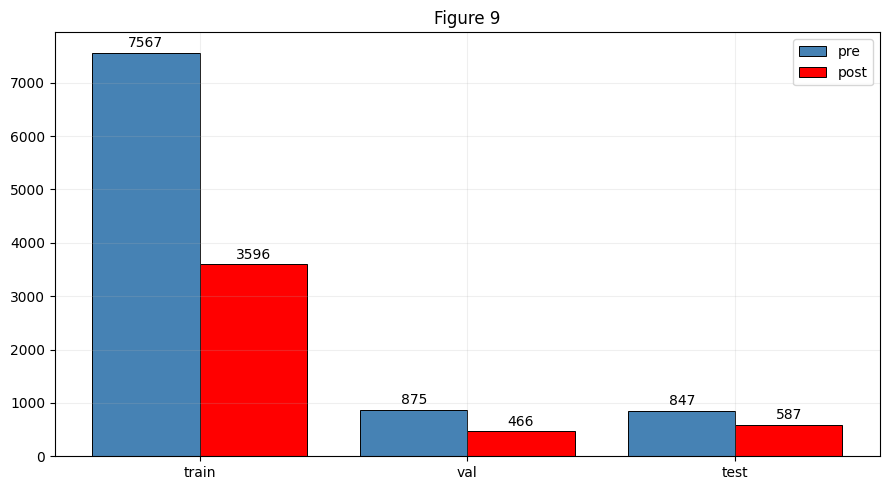

In [10]:
assert set(groups_ev[train_idx]).isdisjoint(groups_ev[val_idx])
assert set(groups_ev[train_idx]).isdisjoint(groups_ev[test_idx])
assert set(groups_ev[val_idx]).isdisjoint(groups_ev[test_idx])

fig2, ax = plt.subplots(figsize=(9, 5))
w = 0.4

for i, (nome, idx) in enumerate([("train", train_idx), ("val", val_idx), ("test", test_idx)]):
    lab = y[idx]
    n_post = int(lab.sum())
    n_pre  = int(len(lab) - lab.sum())
    print(f"{nome}: Eventi Post = {n_post}, Eventi Pre = {n_pre}, Proporzione eventi post = {lab.mean():.3f}")

    b1 = ax.bar(i - w/2, n_pre,  w, color="steelblue", label="pre"  if i == 0 else None, edgecolor="black", linewidth=0.7)
    b2 = ax.bar(i + w/2, n_post, w, color="red",       label="post" if i == 0 else None, edgecolor="black", linewidth=0.7)
    ax.bar_label(b1, padding=2)
    ax.bar_label(b2, padding=2)

ax.set_xticks(range(3))
ax.set_xticklabels(["train", "val", "test"])
ax.set_title("Figure 9")
ax.legend()
ax.grid("on", alpha = 0.2)

fig2.tight_layout()
# fig2.savefig("Figure 9 (Train/Val/Test Splits).png", dpi=150)
plt.show()

# CNN1D

In [11]:
class WaveDataset(Dataset):
    def __init__(self, events, labels, target_len=1000):
        self.events = events
        self.labels = labels
        self.target_len = target_len

    def __len__(self):
        return len(self.events)

    def __getitem__(self, i):
        St, E, D = self.events[i]
        arr = np.stack([tr.data[:self.target_len] for tr in D]).astype(np.float32)

        # normalizzazione per traccia
        arr = arr - arr.mean(axis=1, keepdims=True)
        std = arr.std(axis=1, keepdims=True)
        arr = arr / (std + 1e-8)

        x = torch.from_numpy(arr)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y

In [12]:
train_ds_W = WaveDataset([Events[i] for i in train_idx], y[train_idx])
val_ds_W   = WaveDataset([Events[i] for i in val_idx],   y[val_idx])
test_ds_W  = WaveDataset([Events[i] for i in test_idx],  y[test_idx])


train_loader_Wave = DataLoader(train_ds_W, batch_size=32, shuffle=True, generator = rng_torch) # Togliere Generator per randomness
val_loader_Wave   = DataLoader(val_ds_W,   batch_size=32)
test_loader_Wave  = DataLoader(test_ds_W,  batch_size=32)

In [13]:
class CNN(nn.Module):
    def __init__(self, input_channels=3, output_classes=2):
        super().__init__()
        self.p = 0.3
        self.features = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.MaxPool1d(2),
            nn.ReLU(),

            nn.Dropout(self.p),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),
            nn.ReLU(),

            nn.Dropout(self.p),

            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),
            nn.ReLU(),

            nn.Dropout(self.p),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(2),
            nn.ReLU(),

            # nn.Dropout(self.p),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(2),
            nn.ReLU(),

            # nn.Dropout(self.p),

            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.MaxPool1d(2),
            nn.ReLU(),

            # In caso prova anche un Flatten
            nn.AdaptiveAvgPool1d(1)
        )
        self.lin = nn.Linear(256, output_classes)

    def forward(self, x):            # x: (batch, in_channels, lunghezza)
        x = self.features(x)
        x = x.flatten(1)
        return self.lin(x)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Epochs = 100
OneD_model = CNN().to(device)

class_weights = torch.tensor([1.0, 2.0], device=device)
crit = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
opt = optim.Adam(OneD_model.parameters(), lr=1e-3)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="min",
    factor=0.5,
    patience=10,
    min_lr=8e-5)

In [15]:
history1D = {"train_loss": [], "val_loss": [],
             "train_acc": [], "val_acc": [],
             "val_bacc": [], "val_f1p": []}
best_val_bacc = 0.0
best_state = None


pbar = tqdm(range(Epochs), desc="Training")
for epoch in pbar:
    OneD_model.train()
    tot_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader_Wave:
        x, y = x.to(device), y.to(device)

        opt.zero_grad()
        out = OneD_model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()

        tot_loss += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)

    train_loss = tot_loss / total
    train_acc  = correct / total

    # Validation

    OneD_model.eval()
    tot_loss, total = 0.0, 0
    val_true, val_pred = [], []
    with torch.no_grad():
        for x, y in val_loader_Wave:
            x, y = x.to(device), y.to(device)
            out = OneD_model(x)
            loss = crit(out, y)

            tot_loss += loss.item() * x.size(0)
            total    += x.size(0)
            val_true.append(y.cpu())
            val_pred.append(out.argmax(1).cpu())

    val_loss = tot_loss / total
    val_true = torch.cat(val_true).numpy()
    val_pred = torch.cat(val_pred).numpy()
    val_acc  = (val_true == val_pred).mean()
    val_bacc = balanced_accuracy_score(val_true, val_pred)
    val_f1p  = f1_score(val_true, val_pred, pos_label=1)

    scheduler.step(val_loss)   # da attivare con lo scheduler

    history1D["train_loss"].append(train_loss)
    history1D["val_loss"].append(val_loss)
    history1D["train_acc"].append(train_acc)
    history1D["val_acc"].append(val_acc)
    history1D["val_bacc"].append(val_bacc)
    history1D["val_f1p"].append(val_f1p)

    if not (epoch + 1) % 25:
                  tqdm.write(f"\nEpoch {epoch+1}: train_acc={train_acc:.4f} val_acc={val_acc:.3f} val_bacc={val_bacc:.3f} val_f1p={val_f1p:.3f}")

    if val_bacc > best_val_bacc:
        best_val_bacc = val_bacc
        best_state = copy.deepcopy(OneD_model.state_dict())

OneD_model.load_state_dict(best_state)
print(f"Best val balanced accuracy: {best_val_bacc:.4f}")

Training:  25%|██▌       | 25/100 [01:41<04:55,  3.95s/it]


Epoch 25: train_acc=0.8476 val_acc=0.789 val_bacc=0.778 val_f1p=0.709


Training:  50%|█████     | 50/100 [03:21<03:20,  4.01s/it]


Epoch 50: train_acc=0.9153 val_acc=0.791 val_bacc=0.791 val_f1p=0.725


Training:  75%|███████▌  | 75/100 [04:59<01:36,  3.85s/it]


Epoch 75: train_acc=0.9351 val_acc=0.793 val_bacc=0.785 val_f1p=0.718


Training: 100%|██████████| 100/100 [06:45<00:00,  4.05s/it]


Epoch 100: train_acc=0.9506 val_acc=0.782 val_bacc=0.787 val_f1p=0.719
Best val balanced accuracy: 0.7989


# CNN2D

In [ ]:
class SpecDataset(Dataset):
    def __init__(self, events, labels):
        self.events = events
        self.labels = labels

    def __len__(self):
        return len(self.events)

    def __getitem__(self, i):
        St, E, D = self.events[i]

        specs = []
        for tr in D:
            sig = tr.data[:1000]
            _, _, Zxx = stft(sig, fs=50, nperseg=64, noverlap=48)
            S = np.log1p(np.abs(Zxx))
            S = (S - S.mean()) / (S.std() + 1e-8)
            specs.append(S)

        arr = np.stack(specs).astype(np.float32)
        x = torch.from_numpy(arr)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y

In [ ]:
y = np.array([1 if E in POST_set else 0 for (St, E, D) in Events])
train_ds_S = SpecDataset([Events[i] for i in train_idx], y[train_idx])
val_ds_S   = SpecDataset([Events[i] for i in val_idx],   y[val_idx])
test_ds_S  = SpecDataset([Events[i] for i in test_idx],  y[test_idx])

train_loader_Spec = DataLoader(train_ds_S, batch_size=32, shuffle=True)
val_loader_Spec   = DataLoader(val_ds_S,   batch_size=32)
test_loader_Spec  = DataLoader(test_ds_S,  batch_size=32)

In [ ]:
class CNN2D(nn.Module):
    def __init__(self, input_channels=3, output_classes=2):
        super().__init__()
        self.p = 0.15
        self.features = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.ReLU(),

            nn.Dropout2d(self.p),

            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.ReLU(),

            nn.Dropout2d(self.p),

            nn.Conv2d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.ReLU(),

            # nn.Dropout2d(self.p),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            # nn.MaxPool2d(2),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1)
        )
        self.lin = nn.Linear(256, output_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.lin(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Epochs = 100
TwoD_model = CNN2D().to(device)

weights = torch.tensor([1.0, 2.0], device=device)
crit = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
opt = optim.Adam(TwoD_model.parameters(), lr=1e-3)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="min",
    factor=0.5,
    patience=10,
    min_lr=8e-5)

In [ ]:
history2D = {"train_loss": [], "val_loss": [],
             "train_acc": [], "val_acc": [],
             "val_bacc": [], "val_f1p": []}

best_val_bacc = 0.0
best_state = None

pbar = tqdm(range(Epochs), desc="Training")
for epoch in pbar:
    TwoD_model.train()
    tot_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader_Spec:
        x, y = x.to(device), y.to(device)

        opt.zero_grad()
        out = TwoD_model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()

        tot_loss += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)

    train_loss = tot_loss / total
    train_acc  = correct / total

    # Validation
    TwoD_model.eval()
    tot_loss, total = 0.0, 0
    val_true, val_pred = [], []
    with torch.no_grad():
        for x, y in val_loader_Spec:
            x, y = x.to(device), y.to(device)
            out = TwoD_model(x)
            loss = crit(out, y)

            tot_loss += loss.item() * x.size(0)
            total    += x.size(0)
            val_true.append(y.cpu())
            val_pred.append(out.argmax(1).cpu())

    val_loss = tot_loss / total
    val_true = torch.cat(val_true).numpy()
    val_pred = torch.cat(val_pred).numpy()
    val_acc  = (val_true == val_pred).mean()
    val_bacc = balanced_accuracy_score(val_true, val_pred)
    val_f1p  = f1_score(val_true, val_pred, pos_label=1)

    scheduler.step(val_loss)

    history2D["train_loss"].append(train_loss)
    history2D["val_loss"].append(val_loss)
    history2D["train_acc"].append(train_acc)
    history2D["val_acc"].append(val_acc)
    history2D["val_bacc"].append(val_bacc)
    history2D["val_f1p"].append(val_f1p)

    if not (epoch + 1) % 25:
        tqdm.write(f"\nEpoch {epoch+1}: train_acc={train_acc:.4f} "
                   f"val_acc={val_acc:.3f} val_bacc={val_bacc:.3f} val_f1p={val_f1p:.3f}")

    if val_bacc > best_val_bacc:
        best_val_bacc = val_bacc
        best_state = copy.deepcopy(TwoD_model.state_dict())

TwoD_model.load_state_dict(best_state)
print(f"\nBest val balanced accuracy: {best_val_bacc:.4f}")

Training:  25%|██▌       | 25/100 [08:25<25:16, 20.22s/it]


Epoch 25: 
train_loss=0.3567 
train_acc=0.9195 
val_loss=0.4249 
val_acc=0.896


Training:  50%|█████     | 50/100 [17:04<17:26, 20.93s/it]


Epoch 50: 
train_loss=0.2723 
train_acc=0.9820 
val_loss=0.3998 
val_acc=0.922


Training:  75%|███████▌  | 75/100 [25:38<08:37, 20.70s/it]


Epoch 75: 
train_loss=0.2492 
train_acc=0.9955 
val_loss=0.3893 
val_acc=0.927


Training: 100%|██████████| 100/100 [34:13<00:00, 20.53s/it]


Epoch 100: 
train_loss=0.2422 
train_acc=0.9976 
val_loss=0.3842 
val_acc=0.927

Best val accuracy: 0.9320


# Results Plots

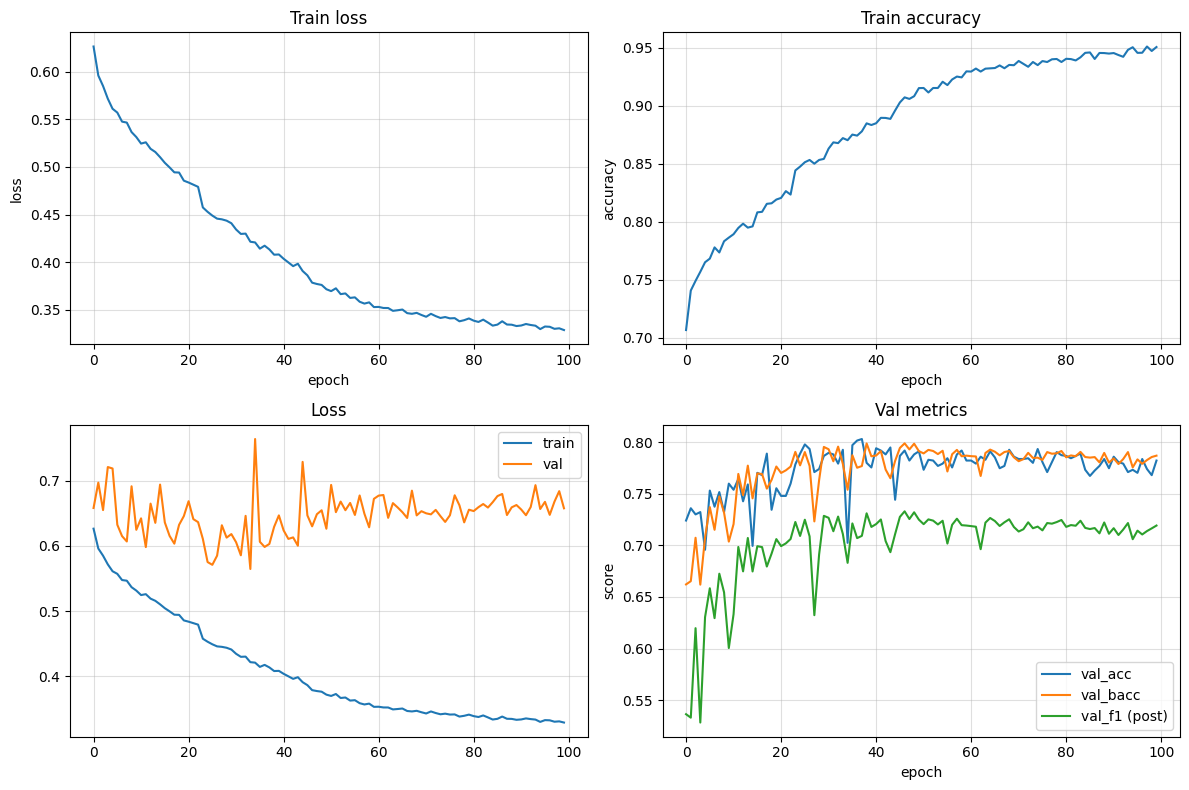

In [16]:
history, Using, model = history1D, "CNN1D", OneD_model

# history, Using, model= history2D, "CNN2D", TwoD_model

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].plot(history["train_loss"])
ax[0, 0].set_title("Train loss")
ax[0, 0].set_xlabel("epoch"); ax[0, 0].set_ylabel("loss")
ax[0, 0].grid(alpha = 0.4)

ax[0, 1].plot(history["train_acc"])
ax[0, 1].set_title("Train accuracy")
ax[0, 1].set_xlabel("epoch"); ax[0, 1].set_ylabel("accuracy")
ax[0, 1].grid(alpha = 0.4)

ax[1, 0].plot(history["train_loss"], label="train")
ax[1, 0].plot(history["val_loss"],   label="val")
ax[1, 0].set_title("Loss"); ax[1, 0].legend(); ax[1, 0].grid(alpha=0.4)
ax[1, 0].grid(alpha = 0.4)

ax[1, 1].plot(history["val_acc"],  label="val_acc")
ax[1, 1].plot(history["val_bacc"], label="val_bacc")
ax[1, 1].plot(history["val_f1p"],  label="val_f1 (post)")
ax[1, 1].set_title("Val metrics")
ax[1, 1].set_xlabel("epoch"); ax[1, 1].set_ylabel("score")
ax[1, 1].legend(); ax[1, 1].grid(alpha=0.4)

fig.tight_layout()
# fig.savefig(f"{Using}: Train and Validation set during Training.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
def get_preds(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            out = model(x.to(device))
            y_pred.extend(out.argmax(1).cpu().numpy())
            y_true.extend(y.numpy())
    return np.array(y_true), np.array(y_pred)

In [18]:
from sklearn.metrics import classification_report, balanced_accuracy_score

model.eval()

tst = test_loader_Wave if Using == "CNN1D" else test_loader_Spec
yt, yp = get_preds(model, tst)

print(classification_report(yt, yp, target_names=["pre","post"], digits=3))

              precision    recall  f1-score   support

         pre      0.836     0.802     0.819       847
        post      0.730     0.773     0.751       587

    accuracy                          0.790      1434
   macro avg      0.783     0.788     0.785      1434
weighted avg      0.793     0.790     0.791      1434



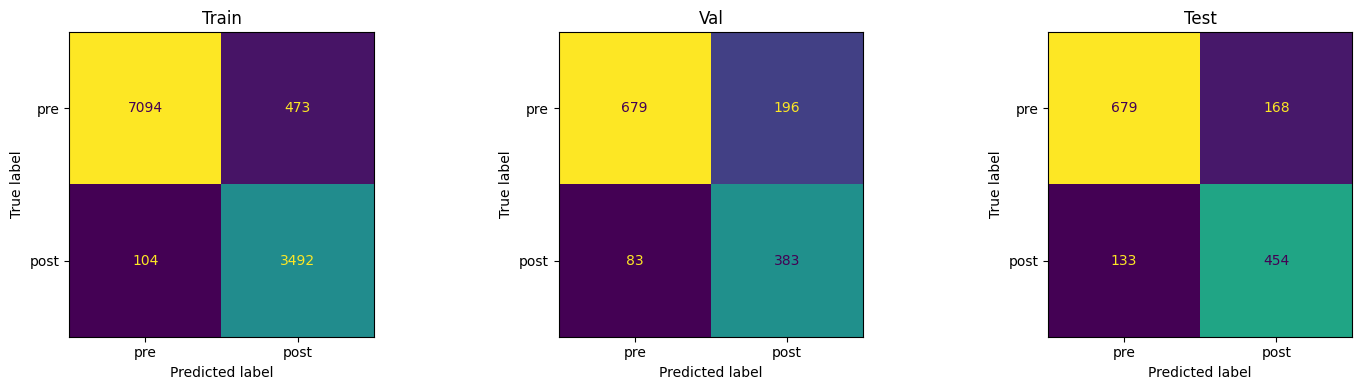

In [19]:
loaders = {"Train": train_loader_Spec, "Val": val_loader_Spec, "Test": test_loader_Spec} if Using == "CNN2D" else {"Train": train_loader_Wave, "Val": val_loader_Wave, "Test": test_loader_Wave}
labels  = ["pre", "post"]        # 0 = pre, 1 = post
model.eval()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, loader) in zip(axes, loaders.items()):
    yt, yp = get_preds(model, loader)
    cm = confusion_matrix(yt, yp, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, colorbar=False)
    ax.set_title(name)

fig.tight_layout()
# fig.savefig(f"{Using}: Confusion Matrices.png", dpi=150, bbox_inches="tight")
plt.show()

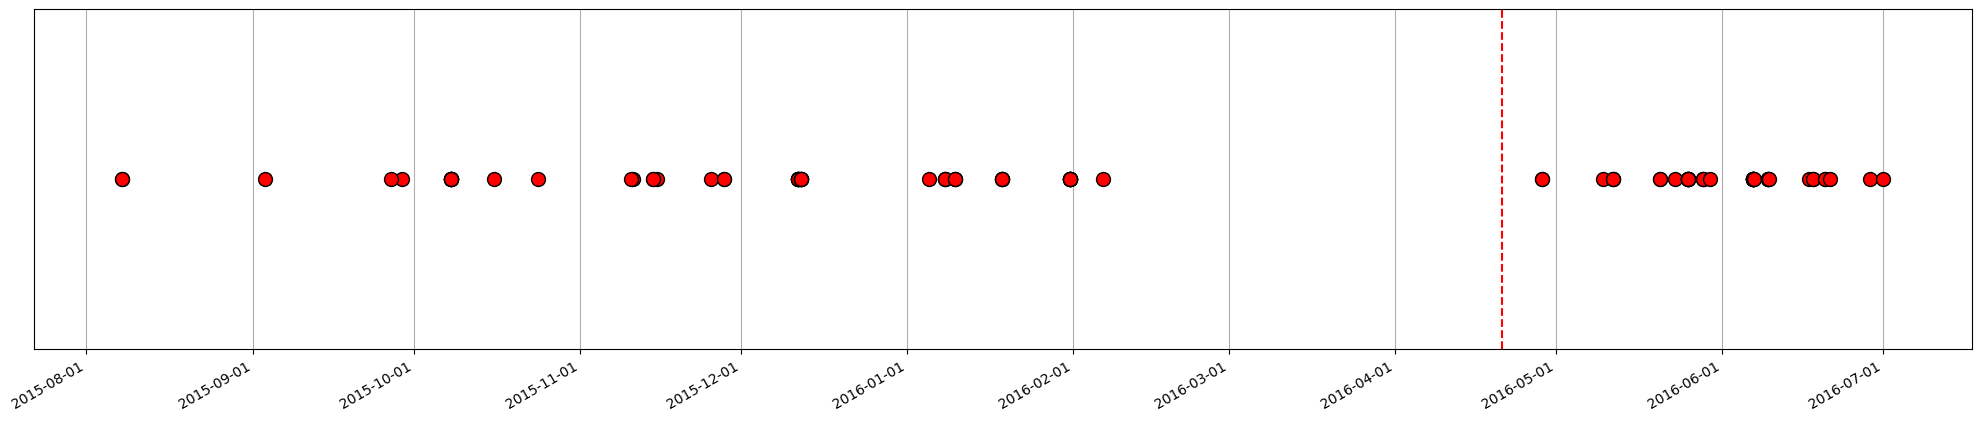

In [ ]:
# mis_idx = np.where(yt != yp)[0]

# test_events = test_ds_W.events if Using == "CNN1D" else test_ds_S.events

# Eventi_Errati = []
# for i in mis_idx:
#     Eventi_Errati.append(test_events[i][1])

# tempi = catalog.loc[Eventi_Errati, "time"]

# fig, ax = plt.subplots(figsize=(25, 5))
# ax.plot(tempi, [0]*len(tempi), "o",color = "red", ms = 10, markeredgecolor="black", markeredgewidth=1)
# ax.yaxis.set_visible(False)
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"),)
# ax.axvline(pd.Timestamp("2016-04-21", tz="UTC") , color="red", linestyle="--")
# ax.grid("on")
# fig.autofmt_xdate()
# fig.savefig(f"{Using}: temporal.png", dpi=150, bbox_inches="tight")
# plt.show()

In [ ]:
# print(history)

{'train_loss': [0.6158436282941249, 0.577714747155997, 0.5508966662275213, 0.5268534992108376, 0.5043343712649135, 0.4864068095527174, 0.47646635550997524, 0.46019565205770563, 0.4509424617216368, 0.44008981328207086, 0.43462274657240485, 0.42731130008928514, 0.417703042018267, 0.41040900252646323, 0.4084881708747825, 0.40038534578687457, 0.39627184166653123, 0.3881380354159997, 0.38353577152767304, 0.3803732084865942, 0.3769167199439961, 0.3694599448384708, 0.36370371634427484, 0.35956558246847004, 0.35671859751209695, 0.35028134862840477, 0.34566300353190216, 0.34261083275359866, 0.3396628661510829, 0.33393301674187054, 0.3322328260129376, 0.31847489296053944, 0.32377741824692774, 0.3200347421398563, 0.3135010970949006, 0.3143239719921148, 0.3092315129326981, 0.30582246389064943, 0.30209107314514577, 0.2966072438035594, 0.2944889542251416, 0.2911408515141998, 0.28817048946844004, 0.2860602163699599, 0.28527203070798474, 0.2836317854003465, 0.28444725206082744, 0.28000117684307085, 0.